In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
import pandas as pd

# Load Auto MPG dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

# Display first five rows
print(df.head())


    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [6]:
#seprate input and output
x =df[['displacement']]
y=df[['mpg']]

print("missing values in ",x.isnull().sum())
print("missing values in mpg:",y.isnull().sum())

missing values in  displacement    0
dtype: int64
missing values in mpg: mpg    0
dtype: int64


In [9]:
# remove rows containing missing values
data = df[['displacement','mpg']].dropna()

#update input and output
x = data[['displacement']]
y =  data['mpg']

print("features")
print(x.head())
print("\nTarget:")
print(y.head())

features
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


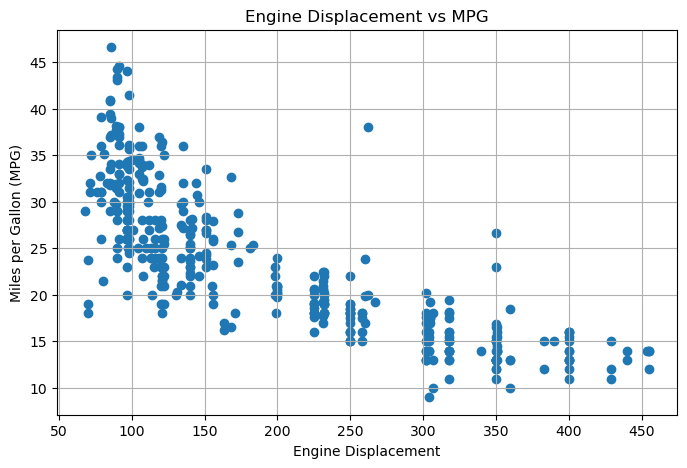

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(x,y)
plt.xlabel("Engine Displacement")
plt.ylabel("Miles per Gallon (MPG)")
plt.title("Engine Displacement vs MPG")
plt.grid(True)
plt.show()

In [19]:
#split the data
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=40
)
print("Training samples:",len(x_train))
print("Testing samples:",len(x_test))
    

Training samples: 318
Testing samples: 80


In [22]:
#Create linear regression
linear_model=LinearRegression()

#Train the model 
linear_model.fit(x_train,y_train)
#predict on test data
y_pred_linear=linear_model.predict(x_test)


In [27]:
#calculate mse
mse_linear=mean_squared_error(y_test,y_pred_linear)
#claculate r square
r2_linear=r2_score(y_test,y_pred_linear)
print(" Linear Regression Result")
print("----------------------------------")
print("MSE:",mse_linear)
print("R_SQUARE:",r2_linear)


 Linear Regression Result
----------------------------------
MSE: 18.012022114560928
R_SQUARE: 0.7255137074557819


In [38]:
# Store results
result = []
polynomial_models = {}

# Linear Regression results
result.append({
    'Model': 'Linear Regression',
    'Degree': 1,
    'MSE': mse_linear,
    'R-Square': r2_linear
})

# Polynomial Regression (Degree 2 to 5)
for degree in range(2, 6):

    poly = PolynomialFeatures(degree=degree)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    poly_model = LinearRegression()
    poly_model.fit(x_train_poly, y_train)

    y_pred_poly = poly_model.predict(x_test_poly)

    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    result.append({
        'Model': 'Polynomial Regression',
        'Degree': degree,
        'MSE': mse,
        'R-Square': r2
    })

    polynomial_models[degree] = {
        'poly': poly,
        'model': poly_model
    }

# Create DataFrame
results_df = pd.DataFrame(result)

# Display results
print(results_df)

                   Model  Degree        MSE  R-Square
0      Linear Regression       1  18.012022  0.725514
1  Polynomial Regression       2  14.359531  0.781174
2  Polynomial Regression       3  14.501028  0.779018
3  Polynomial Regression       4  14.519716  0.778733
4  Polynomial Regression       5  14.454981  0.779720


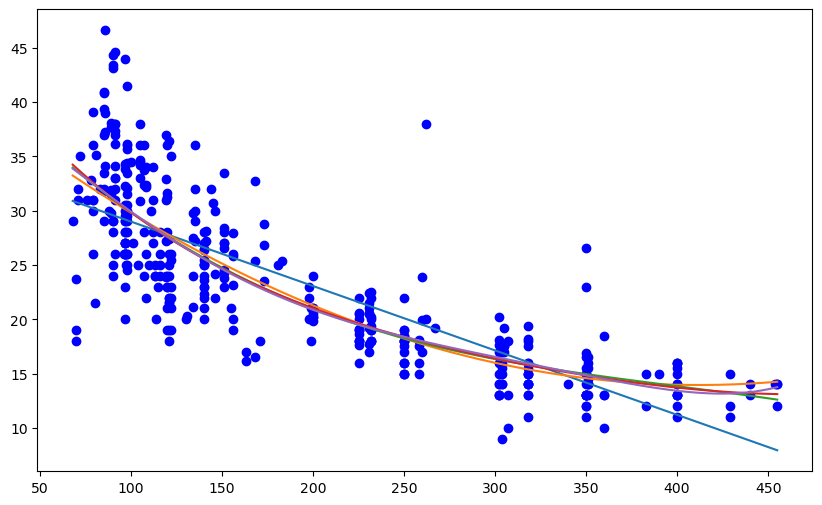

In [51]:

# Create points for plotting the regression curve
x_plot = pd.DataFrame({
    'displacement': np.linspace(
        x['displacement'].min(),
        x['displacement'].max(),
        300
    )
})

# Plot the actual data
plt.figure(figsize=(10, 6))
plt.scatter(
    x['displacement'],
    y,
    label='Actual Data',
    color='blue'
)
y_plot_linear=linear_model.predict(x_plot)
plt.plot(
    x_plot['displacement'],
    y_plot_linear,
    label='Linear  Regression'
)
for degree in range(2,6):
    poly=polynomial_models[degree]['poly']
    poly_model=polynomial_models[degree]['model']
    x_plot_poly=poly.transform(x_plot)
    y_plot_poly=poly_model.predict(x_plot_poly)
    plt.plot(
        x_plot['displacement'],
        y_plot_poly,
        label=f'polynomial degree[degree]'
    )
    

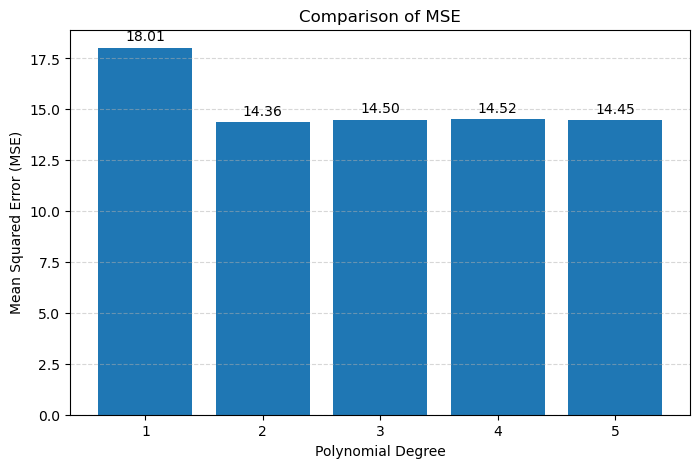

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

plt.bar_label(bars, fmt='%.2f', padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparison of MSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

              

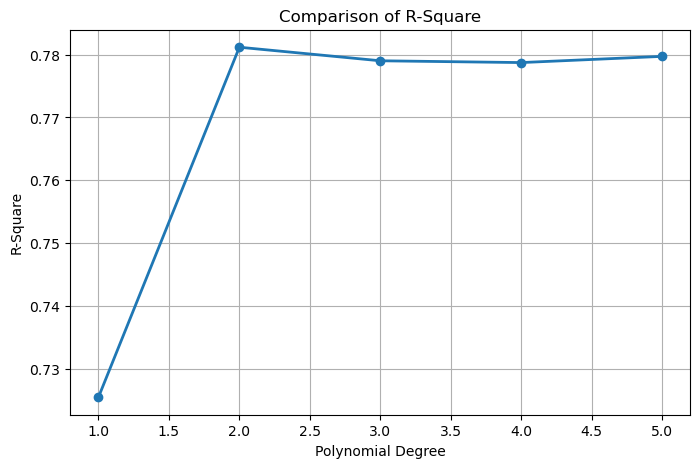

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df['Degree'],
    results_df['R-Square'],
    marker='o',
  
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-Square")
plt.title("Comparison of R-Square")
plt.grid(True)

plt.show()